In [1]:
import pandas as pd
df = pd.read_csv('../data/military_spending_sipri_2024.csv')
df

,Rank,Country,Spending (US$ bn),% of GDP,% of global spending
0,1,United States,997.0,3.4,35.5
1,2,China,314.0,1.7,11.2
2,3,Russia,149.0,7.1,5.5
3,4,Germany,88.5,1.9,3.2
4,5,India,86.1,2.3,3.1
5,6,United Kingdom,81.8,2.3,3.0
6,7,Saudi Arabia,80.3,7.4,3.0
7,8,Ukraine,64.7,34.0,2.4
8,9,France,64.7,2.1,2.4
9,10,Japan,55.3,1.4,2.0


In [2]:
import matplotlib.pyplot as plt

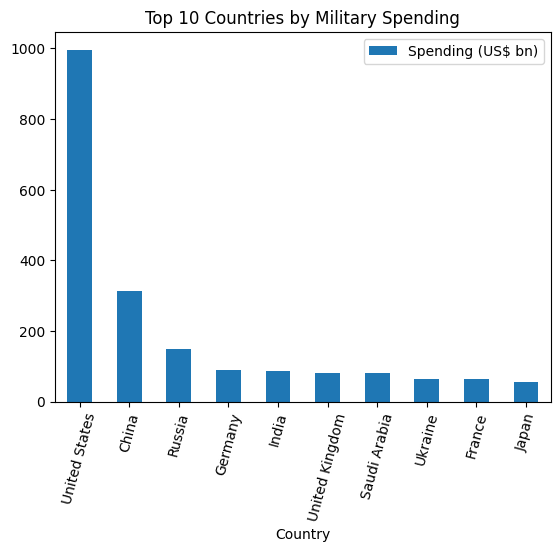

In [3]:
top10_spending = df.sort_values(by='Spending (US$ bn)', ascending=False).head(10)

top10_spending.plot(kind='bar', x='Country', y='Spending (US$ bn)')
plt.title("Top 10 Countries by Military Spending")
plt.xticks(rotation=75)
plt.show()

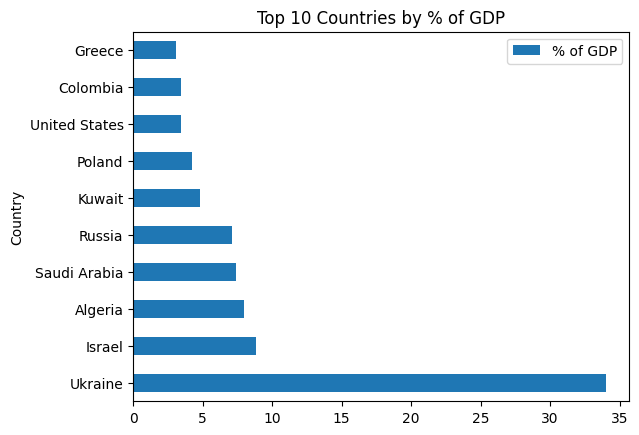

In [4]:
df['% of GDP'] = df['% of GDP'].astype(float)

top10_gdp = df.sort_values(by='% of GDP', ascending=False).head(10)

top10_gdp.plot(kind='barh', x='Country', y='% of GDP')
plt.title("Top 10 Countries by % of GDP")
plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  40 non-null     int64  
 1   Country               40 non-null     object 
 2   Spending (US$ bn)     40 non-null     float64
 3   % of GDP              40 non-null     float64
 4   % of global spending  40 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1.7+ KB


In [6]:
df.isnull().sum()

Rank                    0
Country                 0
Spending (US$ bn)       0
% of GDP                0
% of global spending    0
dtype: int64

In [7]:
region_map = {
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'Brazil': 'South America', 'Colombia': 'South America',
    'China': 'Asia', 'India': 'Asia', 'Japan': 'Asia', 'South Korea': 'Asia',
    'Taiwan': 'Asia', 'Singapore': 'Asia', 'Indonesia': 'Asia', 'Pakistan': 'Asia',
    'Philippines': 'Asia', 'Iran': 'Asia',
    'Russia': 'Europe', 'Germany': 'Europe', 'United Kingdom': 'Europe',
    'Ukraine': 'Europe', 'France': 'Europe', 'Poland': 'Europe', 'Italy': 'Europe',
    'Spain': 'Europe', 'Netherlands': 'Europe', 'Sweden': 'Europe', 'Norway': 'Europe',
    'Denmark': 'Europe', 'Romania': 'Europe', 'Belgium': 'Europe', 'Greece': 'Europe',
    'Finland': 'Europe', 'Switzerland': 'Europe', 'Czech Republic': 'Europe',
    'Turkey': 'Middle East', 'Saudi Arabia': 'Middle East', 'Israel': 'Middle East',
    'Kuwait': 'Middle East', 'Iraq': 'Middle East',
    'Algeria': 'Africa',
    'Australia': 'Oceania'
}
df['Region'] = df['Country'].map(region_map)
df['Region'].value_counts()

Region
Europe           18
Asia             10
Middle East       5
North America     3
South America     2
Oceania           1
Africa            1
Name: count, dtype: int64

In [8]:
df.groupby('Region')['Spending (US$ bn)'].mean().sort_values(ascending=False)

Region
North America    347.666667
Asia              56.980000
Europe            36.133333
Oceania           33.800000
Middle East       33.160000
Africa            21.800000
South America     18.000000
Name: Spending (US$ bn), dtype: float64

In [9]:
# Calculate Estimated GDP ($ bn) based on Military Spending and % of GDP
df['Estimated GDP ($ bn)'] = (df['Spending (US$ bn)'] / df['% of GDP']) * 100
df[['Country', 'Spending (US$ bn)', '% of GDP', 'Estimated GDP ($ bn)']].head()

,Country,Spending (US$ bn),% of GDP,Estimated GDP ($ bn)
0,United States,997.0,3.4,29323.529412
1,China,314.0,1.7,18470.588235
2,Russia,149.0,7.1,2098.591549
3,Germany,88.5,1.9,4657.894737
4,India,86.1,2.3,3743.478261
